In [1]:
!pip install rdkit torch-geometric scikit-learn biopython


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 116.0 MB/s eta 0:00:00


In [20]:

# ========================================
# Imports
# ========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

import pandas as pd
import numpy as np

from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv, global_add_pool

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

from Bio.PDB import PDBParser

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [21]:
import kagglehub
import os

# 1. Download the dataset
download_path = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

# 2. Link it to your local workspace so the notebook can see it
if not os.path.exists('pdbbind_data'):
    os.symlink(download_path, 'pdbbind_data')

print(f"✅ Data linked! You can now access files via 'pdbbind_data/'")
# List files to verify
print("Files in dataset:", os.listdir('pdbbind_data'))


Using Colab cache for faster access to the 'pdbbind-protein-ligand-binding-affinity-dataset' dataset.
✅ Data linked! You can now access files via 'pdbbind_data/'
Files in dataset: ['v2013-core']


In [22]:

# --- 2. ChEMBL Download ---
print("\nDownloading ChEMBL...")
# Downloading Chembel
!wget https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_chemreps.txt.gz -O /content/chembl_36_chemreps.txt.gz
!gzip -d -f /content/chembl_36_chemreps.txt.gz

print("Download & extraction complete!")

# Update Global Variable for downstream cells
CHEMBL_FILE = "/content/chembl_36_chemreps.txt"

# Load and display header for verification
chembl_df = pd.read_csv(CHEMBL_FILE, sep="\t")
print("Columns in file:", chembl_df.columns)
chembl_df.head()


--2026-03-10 18:15:36--  https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/chembl_36_chemreps.txt.gz
Resolving ftp.ebi.ac.uk (ftp.ebi.ac.uk)... 193.62.193.165
Connecting to ftp.ebi.ac.uk (ftp.ebi.ac.uk)|193.62.193.165|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 286873029 (274M) [application/x-gzip]
Saving to: ‘/content/chembl_36_chemreps.txt.gz’

/content/chembl_36_ 100%[===================>] 273.58M  44.8MB/s    in 6.8s    

2026-03-10 18:15:43 (40.3 MB/s) - ‘/content/chembl_36_chemreps.txt.gz’ saved [286873029/286873029]

Download & extraction complete!
Columns in file: Index(['chembl_id', 'canonical_smiles', 'standard_inchi',
       'standard_inchi_key'],
      dtype='object')


,chembl_id,canonical_smiles,standard_inchi,standard_inchi_key
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,MFRNFCWYPYSFQQ-UHFFFAOYSA-N
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,RSEQNZQKBMRQNM-VRGFNVLHSA-N
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,FTKBTEIKPOYCEX-OZSLQWTKSA-N
3,CHEMBL440249,CC(C)C[C@@H]1NC(=O)CNC(=O)[C@H](c2ccc(O)cc2)NC...,InChI=1S/C124H154ClN21O39/c1-57(2)48-81-112(17...,UYSXXKGACMHPIM-KFGDMSGDSA-N
4,CHEMBL405398,Brc1cccc(Nc2ncnc3ccncc23)c1NCCN1CCOCC1,InChI=1S/C19H21BrN6O/c20-15-2-1-3-17(18(15)22-...,VDSXZXJEWIWBCG-UHFFFAOYSA-N


In [23]:
# ========================================
# Atom Feature Engineering
# ========================================

def atom_features(atom):

    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        atom.GetTotalNumHs(),
        int(atom.GetIsAromatic()),
        atom.GetHybridization().real,
        atom.GetTotalValence(),
        int(atom.IsInRing())
    ]


# ========================================
# Bond Features
# ========================================

def bond_features(bond):

    return [
        bond.GetBondTypeAsDouble(),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]


# ========================================
# SMILES → Graph
# ========================================

def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    x = []
    edge_index = []
    edge_attr = []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features(bond)

        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

In [24]:
# ========================================
# Load ChEMBL
# ========================================

chembl = pd.read_csv(
    "chembl_36_chemreps.txt",
    sep="\t"
)

print("Total molecules:", len(chembl))

# Use subset for Colab
chembl = chembl.head(150000)

smiles_list = chembl["canonical_smiles"].dropna().tolist()


# ========================================
# Convert SMILES → Graphs
# ========================================

chembl_graphs = []

for smi in tqdm(smiles_list):

    g = smiles_to_graph(smi)

    if g is not None:
        chembl_graphs.append(g)

print("Valid graphs:", len(chembl_graphs))


chembl_loader = DataLoader(
    chembl_graphs,
    batch_size=128,
    shuffle=True
)

Total molecules: 2854815


100%|██████████| 150000/150000 [02:09<00:00, 1160.72it/s]

Valid graphs: 149996


In [25]:
# ========================================
# GNN Encoder
# ========================================

class MolecularEncoder(nn.Module):

    def __init__(self, node_dim, edge_dim, hidden=128):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(node_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn2 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn3 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)
        self.conv3 = GINEConv(nn3, edge_dim=edge_dim)

    def forward(self, data):

        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        return x

In [26]:
# ========================================
# Initialize Model
# ========================================

sample = chembl_graphs[0]

node_dim = sample.x.shape[1]
edge_dim = sample.edge_attr.shape[1]

encoder = MolecularEncoder(node_dim, edge_dim).to(device)

optimizer = torch.optim.Adam(
    encoder.parameters(),
    lr=1e-3
)


# ========================================
# Pretraining Loop
# ========================================

EPOCHS = 10

for epoch in range(EPOCHS):

    encoder.train()

    total_loss = 0

    for batch in chembl_loader:

        batch = batch.to(device)
        # Ensure edge_index is of integer type
        if batch.edge_index.dtype != torch.long:
            batch.edge_index = batch.edge_index.long()

        optimizer.zero_grad()

        node_embeddings = encoder(batch)

        graph_embeddings = global_add_pool(
            node_embeddings,
            batch.batch
        )

        # simple contrastive-style objective
        loss = torch.mean(graph_embeddings**2)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} Loss:",
        total_loss / len(chembl_loader)
    )


# Save pretrained encoder
torch.save(
    encoder.state_dict(),
    "chembl_pretrained_encoder.pt"
)

print("Pretraining complete.")

Epoch 1 Loss: 0.24952673305540696
Epoch 2 Loss: 6.343035983573622e-13
Epoch 3 Loss: 5.793664308475896e-17
Epoch 4 Loss: 3.0932602510651923e-22
Epoch 5 Loss: 0.0
Epoch 6 Loss: 0.0
Epoch 7 Loss: 0.0
Epoch 8 Loss: 0.0
Epoch 9 Loss: 0.0
Epoch 10 Loss: 0.0
Pretraining complete.


In [27]:
# ========================================
# 1. Helper: Mol to Graph
# ========================================

def mol_to_graph(mol):
    if mol is None:
        return None

    x = []
    edge_index = []
    edge_attr = []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        bf = bond_features(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)
    # Explicitly set edge_index to long to avoid type errors
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)


# ========================================
# 2. Load PDBBind Data
# ========================================

pdb_df = pd.read_csv("pdbbind_data/v2013-core/pdbbind_v2013_core.csv")
print("PDBBind samples in CSV:", len(pdb_df))

pdbbind_graphs = []

for idx, row in tqdm(pdb_df.iterrows(), total=len(pdb_df)):
    pdb_id = row['pdb_id']
    affinity = row['label']

    # Path to the ligand SDF file
    sdf_path = f"pdbbind_data/v2013-core/{pdb_id}/{pdb_id}_ligand.sdf"

    # Load Molecule
    if os.path.exists(sdf_path):
        suppl = Chem.SDMolSupplier(sdf_path)
        mol = next(iter(suppl), None)

        if mol is not None:
            g = mol_to_graph(mol)
            if g is not None:
                g.y = torch.tensor([affinity], dtype=torch.float)
                pdbbind_graphs.append(g)

print(f"\nSuccessfully processed {len(pdbbind_graphs)} valid complexes.")

# Create Loader
pdbbind_loader = DataLoader(
    pdbbind_graphs,
    batch_size=16,
    shuffle=True
)

PDBBind samples in CSV: 193


  0%|          | 0/193 [00:00<?, ?it/s][18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Explicit valence for atom # 50 C, 4, is greater than permitted
[18:22:08] ERROR: Could not sanitize molecule ending on line 287
[18:22:08] ERROR: Explicit valence for atom # 50 C, 4, is greater than permitted
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[18:22:08] Warning: molecule is tagged as 2D, but at least one Z coor


Successfully processed 182 valid complexes.


In [28]:
# ==========================================
# PDBBind Dataset Loader
# ==========================================

import os

pdbbind_dir = "pdbbind_data"

pdb_ids = os.listdir(pdbbind_dir)

dataset = []

for pdb_id in tqdm(pdb_ids):

    folder = os.path.join(pdbbind_dir, pdb_id)

    ligand_file = os.path.join(folder, f"{pdb_id}_ligand.sdf")
    protein_file = os.path.join(folder, f"{pdb_id}_protein.pdb")

    if not os.path.exists(ligand_file):
        continue

    try:

        suppl = Chem.SDMolSupplier(ligand_file)
        mol = suppl[0]

        if mol is None:
            continue

        smiles = Chem.MolToSmiles(mol)

        ligand_graph = smiles_to_graph(smiles)

        if ligand_graph is None:
            continue

        dataset.append({
            "ligand_graph": ligand_graph,
            "protein_file": protein_file,
            "pdb_id": pdb_id
        })

    except:
        continue

print("Loaded complexes:", len(dataset))

100%|██████████| 1/1 [00:00<00:00, 6533.18it/s]

Loaded complexes: 0


In [29]:
import os
import glob
from rdkit import Chem
from rdkit import RDLogger
import torch
from torch_geometric.data import Data
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Suppress RDKit warnings
RDLogger.DisableLog('rdApp.*')

# 1. Setup Path
data_path = "pdbbind_data"

# Check if the local symlink/directory exists
if os.path.exists(data_path):
    pdbbind_dir = data_path
else:
    # Fallback to downloading if not found locally
    import kagglehub
    pdbbind_dir = kagglehub.dataset_download("madukacharles/pdbbind-protein-ligand-binding-affinity-dataset")

print(f"Using PDBBind directory: {pdbbind_dir}")

# 2. Define Helper to convert Mol to Graph
def mol_to_graph_pdb(mol, target=None):
    if mol is None: return None

    # Reuse atom_features if available
    try:
        x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float)
    except NameError:
        # Fallback if atom_features not in scope
        return None

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        edge_attr += [[bond.GetBondTypeAsDouble()], [bond.GetBondTypeAsDouble()]]

    edge_index = torch.tensor(edge_index).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)
    y = torch.tensor([target], dtype=torch.float) if target is not None else None

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# 3. Load Data
pdbbind_graphs = []

# Strategy: Look for CSV first (common in Kaggle datasets), then standard index files
csv_files = glob.glob(os.path.join(pdbbind_dir, '**', '*.csv'), recursive=True)
index_files = glob.glob(os.path.join(pdbbind_dir, '**', '*index*'), recursive=True)

data_list = []

if csv_files:
    csv_file = csv_files[0]
    print(f"Found CSV index file: {csv_file}")
    df = pd.read_csv(csv_file)

    # Clean column names (strip whitespace and lower case)
    df.columns = [c.strip().lower() for c in df.columns]
    print(f"Columns in file: {df.columns.tolist()}")

    # Heuristic to find PDB ID and Affinity columns
    # Added 'label' to affinity keywords
    id_col = next((c for c in df.columns if 'pdb' in c or 'code' in c), None)
    aff_col = next((c for c in df.columns if 'affinity' in c or 'log' in c or 'target' in c or 'label' in c), None)

    # Fallback to indices if names fail
    if not id_col or not aff_col:
        # Case: 2 columns (likely ID, Label)
        if len(df.columns) == 2:
            print("⚠️ Header matching failed but found 2 columns. Assuming (0 -> ID, 1 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[1]
        # Case: Standard PDBBind (Col 0 = ID, Col 3 = Affinity)
        elif len(df.columns) >= 4:
            print("⚠️ Header matching failed. Trying column indices (0 -> ID, 3 -> Affinity)...")
            id_col = df.columns[0]
            aff_col = df.columns[3]

    if id_col and aff_col:
        print(f"Parsing CSV with ID column '{id_col}' and Affinity column '{aff_col}'")
        for _, row in df.iterrows():
            try:
                val = float(row[aff_col])
                data_list.append((str(row[id_col]), val))
            except ValueError:
                continue
    else:
        print("⚠️ Could not identify ID or Affinity columns in CSV. Falling back to directory scan.")

elif index_files:
    # Fallback to standard PDBBind index parsing
    index_file = [f for f in index_files if not f.endswith('.csv')][0]
    print(f"Using standard index file: {index_file}")

    with open(index_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        if line.startswith("#"): continue
        parts = line.split()
        if len(parts) < 4: continue

        pdb_id = parts[0]
        try:
            affinity = float(parts[3])
            data_list.append((pdb_id, affinity))
        except ValueError:
            continue

# Process the collected data list
count = 0
if data_list:
    print(f"Processing {len(data_list)} entries from index...")
    for pdb_id, affinity in data_list:
        # Look for ligand file
        ligand_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.sdf"), recursive=True)
        mol2_files = glob.glob(os.path.join(pdbbind_dir, '**', pdb_id, f"*ligand.mol2"), recursive=True)

        mol = None
        if ligand_files:
            suppl = Chem.SDMolSupplier(ligand_files[0])
            mol = suppl[0] if len(suppl) > 0 else None
        elif mol2_files:
            mol = Chem.MolFromMol2File(mol2_files[0])

        if mol:
            g = mol_to_graph_pdb(mol, affinity)
            if g:
                pdbbind_graphs.append(g)
                count += 1

        if count >= 2000: break
else:
    # STRICT MODE: Do not load dummy data
    print("❌ No valid index found and 'Strict Mode' is on. Real affinity data is required.")
    print("Please check that the PDBBind dataset contains a valid CSV or index file.")

print(f"Loaded {len(pdbbind_graphs)} PDBBind graphs.")

if len(pdbbind_graphs) > 0:
    train_graphs, test_graphs = train_test_split(pdbbind_graphs, test_size=0.2, random_state=42)
    train_graphs, val_graphs = train_test_split(train_graphs, test_size=0.2, random_state=42)

    train_targets = np.array([g.y.item() for g in train_graphs])
    val_targets = np.array([g.y.item() for g in val_graphs])
    test_targets = np.array([g.y.item() for g in test_graphs])

    print(f"Refreshed Splits -> Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")
else:
    print("❌ No graphs loaded from PDBBind. Please check the dataset.")

Using PDBBind directory: pdbbind_data
Found CSV index file: pdbbind_data/v2013-core/pdbbind_v2013_core.csv
Columns in file: ['pdb_id', 'label']
Parsing CSV with ID column 'pdb_id' and Affinity column 'label'
Processing 193 entries from index...
Loaded 182 PDBBind graphs.
Refreshed Splits -> Train: 116, Val: 29, Test: 37


In [30]:
# ==========================================
# Protein Pocket Extraction
# ==========================================

parser = PDBParser(QUIET=True)

def extract_pocket_atoms(protein_file, ligand_coords, cutoff=3.5):

    structure = parser.get_structure("protein", protein_file)

    pocket_atoms = []

    for atom in structure.get_atoms():

        atom_coord = atom.get_coord()

        for lig_coord in ligand_coords:

            dist = np.linalg.norm(atom_coord - lig_coord)

            if dist < cutoff:

                pocket_atoms.append(atom)

                break

    return pocket_atoms

In [31]:
# Pocket extraction test
import os
from rdkit import Chem

# 1. Pick a sample from the loaded list
if 'data_list' in globals() and data_list:
    sample_pdb_id = data_list[0][0]
    print(f"Testing with PDB ID: {sample_pdb_id}")

    # 2. Define paths
    base_path = "pdbbind_data/v2013-core"
    protein_file = os.path.join(base_path, sample_pdb_id, f"{sample_pdb_id}_protein.pdb")
    ligand_file = os.path.join(base_path, sample_pdb_id, f"{sample_pdb_id}_ligand.sdf")

    # 3. Load Ligand to get coordinates
    if os.path.exists(ligand_file) and os.path.exists(protein_file):
        suppl = Chem.SDMolSupplier(ligand_file)
        mol = next(iter(suppl), None)

        if mol:
            ligand_coords = mol.GetConformer().GetPositions()
            print(f"Ligand Coordinates Shape: {ligand_coords.shape}")

            # 4. Call the function
            pocket_atoms = extract_pocket_atoms(protein_file, ligand_coords, cutoff=3.5)
            print(f"Extracted {len(pocket_atoms)} atoms in the binding pocket.")
        else:
            print("Error: Could not parse ligand molecule.")
    else:
        print(f"Error: Files not found for {sample_pdb_id}")
else:
    print("Error: data_list not defined. Please run the data loading cells first.")

Testing with PDB ID: 2d3u
Ligand Coordinates Shape: (27, 3)
Extracted 11 atoms in the binding pocket.


In [32]:
# Fragment Builder cell.
from rdkit import Chem
from rdkit.Chem import rdchem

def build_fragment_molecule(ligand_mol, pocket_atoms):

    frag = Chem.RWMol()

    # add ligand atoms
    for atom in ligand_mol.GetAtoms():
        frag.AddAtom(atom)

    # add protein pocket atoms
    for atom in pocket_atoms:
        element = atom.element
        a = Chem.Atom(element)
        frag.AddAtom(a)

    return frag.GetMol()

In [33]:
#libraries
!pip install "qiskit==0.45.2" "qiskit-nature==0.6.2" "qiskit-machine-learning==0.7.1" pyscf

In [34]:
# Retry imports after qiskit downgrade
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.problems import ElectronicStructureProblem
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.algorithms import VQEUCCFactory
from qiskit.algorithms.optimizers import SLSQP
from qiskit.primitives import Estimator
from qiskit.algorithms import VQE

In [35]:
# VQE HOMO / LUMO Calculation
def compute_homo_lumo(smiles):

    try:

        driver = PySCFDriver(
            atom=smiles,
            basis="sto3g"
        )

        problem = ElectronicStructureProblem(driver)

        second_q_ops = problem.second_q_ops()
        hamiltonian = second_q_ops[0]

        mapper = JordanWignerMapper()

        qubit_op = mapper.map(hamiltonian)

        optimizer = SLSQP(maxiter=50)

        vqe = VQE(
            estimator=Estimator(),
            ansatz=None,
            optimizer=optimizer
        )

        result = vqe.compute_minimum_eigenvalue(qubit_op)

        eigenvalues = result.eigenvalue.real

        # approximate HOMO/LUMO
        homo = eigenvalues
        lumo = eigenvalues + 0.1

        return homo, lumo

    except:
        return None, None

In [36]:
def quantum_atom_features(atom, homo, lumo):

    return [
        homo,
        lumo,
        lumo - homo,   # band gap
        atom.GetAtomicNum()
    ]

In [37]:
# Quantum Kernel Edge Mapping
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import ZZFeatureMap

feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

def quantum_edge_features(distances):

    distances = np.array(distances)

    kernel_matrix = quantum_kernel.evaluate(distances)

    return kernel_matrix

In [38]:
# ==========================================
# Protein Graph Builder (Quantum Enhanced)
# ==========================================

# ⚠️ EDIT 1 — Import quantum kernel tools
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.circuit.library import PauliFeatureMap


# ⚠️ EDIT 2 — Create Quantum Kernel (once)
# Use PauliFeatureMap with only 'Z' to allow feature_dimension=1
feature_map = PauliFeatureMap(feature_dimension=1, reps=2, paulis=['Z'])

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)


# ⚠️ EDIT 3 — Quantum Feature Calculator
# (placeholder for VQE HOMO/LUMO extractor)

def compute_homo_lumo(atom):

    # In real pipeline this will come from VQE simulation
    # Here we approximate using atomic number

    atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(atom.element)

    homo = atomic_num * 0.1
    lumo = atomic_num * 0.1 + 0.05

    return homo, lumo


def protein_atoms_to_graph(pocket_atoms):

    node_features = []
    coords = []

    for atom in pocket_atoms:

        element = atom.element
        atomic_num = Chem.GetPeriodicTable().GetAtomicNumber(element)

        # ======================================
        # ⚠️ EDIT 4 — Compute Quantum Features
        # ======================================

        homo, lumo = compute_homo_lumo(atom)

        gap = lumo - homo

        node_features.append([
            homo,
            lumo,
            gap,
            atomic_num
        ])

        coords.append(atom.get_coord())

    coords = np.array(coords)

    edge_index = []
    distances = []


    # ======================================
    # Build geometric edges
    # ======================================

    for i in range(len(coords)):
        for j in range(len(coords)):

            if i == j:
                continue

            dist = np.linalg.norm(coords[i] - coords[j])

            if dist < 4.5:

                edge_index.append([i, j])
                distances.append([dist])


    if len(edge_index) == 0:
        return None


    # ======================================
    # ⚠️ EDIT 5 — Quantum Kernel Edge Mapping
    # ======================================

    distances = np.array(distances)

    kernel_matrix = quantum_kernel.evaluate(distances)

    edge_attr = []

    for k in range(len(edge_index)):
        edge_attr.append([kernel_matrix[k][k]])

    # ======================================
    # Convert to PyTorch tensors
    # ======================================

    x = torch.tensor(node_features, dtype=torch.float)

    edge_index = torch.tensor(edge_index).t().contiguous()

    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    return Data(
        x=x,
        edge_index=edge_index,
        edge_attr=edge_attr
    )

In [39]:
# ==========================================
# Dual GNN Model (Quantum-Enhanced Version)
# ==========================================

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINEConv, global_add_pool

class DualGNN(nn.Module):

    def __init__(self, ligand_encoder, protein_node_dim=4):   # ⚠️ EDIT 1

        super().__init__()

        self.ligand_encoder = ligand_encoder

        hidden = 128

        # ⚠️ EDIT 2
        # Input dimension changed because protein node features
        # now contain quantum electronic descriptors
        nn1 = nn.Sequential(
            nn.Linear(protein_node_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        # ⚠️ EDIT 3
        # edge_dim still = 1 but now represents
        # Quantum Kernel similarity instead of distance
        self.protein_conv = GINEConv(nn1, edge_dim=1)

        self.fc = nn.Sequential(

            nn.Linear(hidden * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )

    def forward(self, ligand_data, protein_data):

        # ======================================
        # Ligand Encoder (unchanged)
        # ======================================

        ligand_x = self.ligand_encoder(ligand_data)

        ligand_emb = global_add_pool(
            ligand_x,
            ligand_data.batch
        )

        # ======================================
        # Protein GNN
        # ======================================

        # ⚠️ EDIT 4
        # protein_data.x now contains:
        # [HOMO, LUMO, HOMO-LUMO GAP, Atomic Number]

        px = F.relu(
            self.protein_conv(
                protein_data.x,
                protein_data.edge_index,

                # ⚠️ EDIT 5
                # edge_attr now contains
                # Quantum Kernel Similarity
                protein_data.edge_attr
            )
        )

        protein_emb = global_add_pool(
            px,
            protein_data.batch
        )

        # ======================================
        # Fusion Layer
        # ======================================

        combined = torch.cat(
            [ligand_emb, protein_emb],
            dim=1
        )

        return self.fc(combined)

In [40]:
# ========================================
# GNN Encoder Definition (Missing Dependency)
# ========================================

import os

class MolecularEncoder(nn.Module):

    def __init__(self, node_dim, edge_dim, hidden=128):

        super().__init__()

        nn1 = nn.Sequential(
            nn.Linear(node_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn2 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        nn3 = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden)
        )

        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)
        self.conv3 = GINEConv(nn3, edge_dim=edge_dim)

    def forward(self, data):

        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))

        return x

# ==========================================
# Load Pretrained Encoder
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the encoder first
# We need to know the dimensions. Based on previous cells:
# node_dim = 8 (from atom_features)
# edge_dim = 3 (from bond_features)
node_dim = 8
edge_dim = 3

encoder = MolecularEncoder(node_dim, edge_dim).to(device)

# Load weights
if os.path.exists("chembl_pretrained_encoder.pt"):
    encoder.load_state_dict(
        torch.load("chembl_pretrained_encoder.pt", map_location=device)
    )
else:
    print("Warning: Pretrained weights not found. Using random initialization.")

model = DualGNN(encoder).to(device)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

criterion = nn.MSELoss()

In [41]:
# ==========================================
# Build Final Dataset (Strict Mode)
# ==========================================

ligand_graphs = []
protein_graphs = []
targets = []

# Ensure we have data_list (truth labels)
if 'data_list' not in globals() or not data_list:
    print("Skipping this cell: 'data_list' is missing (no labels available).")
else:
    # Convert data_list to a dict for fast lookup: pdb_id -> affinity
    affinity_map = {item[0]: item[1] for item in data_list}

    for item in dataset:
        pdb_id = item.get("pdb_id")
        ligand_graph = item["ligand_graph"]
        protein_file = item["protein_file"]

        # Lookup real affinity
        real_affinity = affinity_map.get(pdb_id)

        if real_affinity is None:
            # Skip if no real label exists
            continue

        try:
            # Get ligand coordinates (re-derivation attempt)
            # Note: Ideally we should pass coordinates from the source, but sticking to logic structure:
            mol = Chem.MolFromSmiles(Chem.MolToSmiles(Chem.MolFromSmiles(
                Chem.MolToSmiles(Chem.MolFromSmiles(Chem.MolToSmiles))
            )))
            # This triple-conversion is unstable/invalid in most contexts without an input object
            # Assuming 'mol' is derived from 'ligand_graph' or similar in original intent
            # For safety, let's skip complex coord regen if implicit.

            # ... [Skipping unstable coord regen block for safety in this strict pass] ...
            pass

            # We will rely on the main training cell (pj7qmfmIvhSg) for the actual dual dataset construction
            # This cell is largely superseded by the robust loader in pj7qmfmIvhSg

        except:
            continue

    print("Note: This specific dataset construction cell is deprecated in favor of the robust training loop below.")
    print("Please proceed to the training cell which handles full graph construction with real labels.")

Note: This specific dataset construction cell is deprecated in favor of the robust training loop below.
Please proceed to the training cell which handles full graph construction with real labels.


In [42]:
from torch_geometric.data import Batch
import os

# --- Helper: Ensure Features Match Encoder ---
def bond_features_fixed(bond):
    return [
        bond.GetBondTypeAsDouble(),
        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

def mol_to_graph_pdb_fixed(mol, target=None):
    if mol is None: return None

    # Atom features (reuse existing function if available, else standard)
    x = []
    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    edge_index = []
    edge_attr = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])

        # Use 3 features to match pretrained encoder
        bf = bond_features_fixed(bond)
        edge_attr.append(bf)
        edge_attr.append(bf)

    x = torch.tensor(x, dtype=torch.float)
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_attr, dtype=torch.float)

    if target is not None:
        # Ensure target is a tensor
        y = torch.tensor([target], dtype=torch.float)
        return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# --- 1. Define Collate Function ---
def collate_dual_graphs(batch):
    ligands, proteins, targets = zip(*batch)
    ligand_batch = Batch.from_data_list(ligands)
    protein_batch = Batch.from_data_list(proteins)
    y = torch.cat(targets)
    return ligand_batch, protein_batch, y

# --- 2. Prepare Dataset ---
print("Preparing Data for Training (Strict Mode: Real Data Only)...")
dual_dataset = []

# Handle Path Structure (v2013-core subdir check)
base_path = "pdbbind_data"
if os.path.exists(os.path.join(base_path, "v2013-core")):
    base_path = os.path.join(base_path, "v2013-core")

# STRICT DATA LOADING
# We must rely on 'data_list' populated from the CSV/Index file in previous cells.
# If data_list is missing, we stop.
if 'data_list' not in globals() or not data_list:
    raise ValueError("CRITICAL: 'data_list' is empty or undefined. Real affinity labels are missing. Please run the cell that parses the PDBBind index/CSV file first.")

candidates = data_list

# We'll limit processing to a subset for speed, but using REAL samples
process_limit = 300
count = 0

for pdb_id, aff in tqdm(candidates):
    if count >= process_limit: break

    lig_path = os.path.join(base_path, pdb_id, f"{pdb_id}_ligand.sdf")
    prot_path = os.path.join(base_path, pdb_id, f"{pdb_id}_protein.pdb")

    if not os.path.exists(lig_path) or not os.path.exists(prot_path):
        continue

    try:
        # Load Ligand
        suppl = Chem.SDMolSupplier(lig_path)
        mol = next(iter(suppl), None)
        if mol is None: continue

        # Use FIXED graph converter
        lig_g = mol_to_graph_pdb_fixed(mol, aff)
        if lig_g is None: continue

        # Load Protein Pocket
        lig_coords = mol.GetConformer().GetPositions()
        pocket_atoms = extract_pocket_atoms(prot_path, lig_coords)
        prot_g = protein_atoms_to_graph(pocket_atoms)

        if prot_g is None: continue

        target_tensor = torch.tensor([aff], dtype=torch.float)
        dual_dataset.append((lig_g, prot_g, target_tensor))
        count += 1
    except:
        continue

print(f"Processed {len(dual_dataset)} real samples.")

if len(dual_dataset) > 0:
    # --- 3. Create Loader ---
    train_loader = torch.utils.data.DataLoader(
        dual_dataset,
        batch_size=16,
        shuffle=True,
        collate_fn=collate_dual_graphs
    )

    # --- 4. Training Loop ---
    EPOCHS = 30
    train_losses = []  # Initialize the list to store losses

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for ligand_batch, protein_batch, y in train_loader:
            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)
            y = y.to(device)

            optimizer.zero_grad()
            pred = model(ligand_batch, protein_batch)
            loss = criterion(pred.squeeze(), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss) # Store the loss
        print(f"Epoch {epoch+1} Loss: {avg_loss:.4f}")
else:
    print("Error: No valid samples loaded. Check dataset paths.")

Preparing Data for Training (Strict Mode: Real Data Only)...


100%|██████████| 193/193 [25:18<00:00,  7.87s/it]


Processed 147 real samples.
Epoch 1 Loss: 81.4739
Epoch 2 Loss: 27.4664
Epoch 3 Loss: 19.9989
Epoch 4 Loss: 15.0826
Epoch 5 Loss: 13.1493
Epoch 6 Loss: 7.1703
Epoch 7 Loss: 6.3301
Epoch 8 Loss: 6.3485
Epoch 9 Loss: 6.6492
Epoch 10 Loss: 5.8723
Epoch 11 Loss: 6.2374
Epoch 12 Loss: 6.5343
Epoch 13 Loss: 5.2137
Epoch 14 Loss: 5.3705
Epoch 15 Loss: 5.6876
Epoch 16 Loss: 5.0835
Epoch 17 Loss: 5.6265
Epoch 18 Loss: 4.8398
Epoch 19 Loss: 4.9537
Epoch 20 Loss: 5.5122
Epoch 21 Loss: 5.6702
Epoch 22 Loss: 4.6697
Epoch 23 Loss: 7.8870
Epoch 24 Loss: 14.0802
Epoch 25 Loss: 7.6247
Epoch 26 Loss: 5.5178
Epoch 27 Loss: 5.8866
Epoch 28 Loss: 5.4338
Epoch 29 Loss: 5.6812
Epoch 30 Loss: 4.9694


In [43]:
# ==========================================
# Evaluation
# ==========================================

# Ensure we have the necessary imports locally if needed
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import torch

# 1. Create Test Loader
# Unconditionally create/overwrite test_loader to ensure it uses the correct collate_fn
if 'dual_dataset' not in globals() or not dual_dataset:
    print("Error: dual_dataset not found. Please run the training cell first.")
else:
    # Split 80/20 (re-calculating split to ensure consistency)
    split_idx = int(0.8 * len(dual_dataset))
    test_data = dual_dataset[split_idx:]

    if len(test_data) == 0:
         print("Warning: Test set empty, evaluating on Train set.")
         test_data = dual_dataset

    # Re-instantiate loader to guarantee correct collate_fn usage
    test_loader = torch.utils.data.DataLoader(
        test_data,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_dual_graphs
    )

    # 2. Run Evaluation
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for ligand_batch, protein_batch, y in test_loader:

            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)

            pred = model(ligand_batch, protein_batch)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    # Metrics
    if len(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)

        print("Evaluation Results:")
        print("R²:", r2)
        print("RMSE:", rmse)
        print("MAE:", mae)
    else:
        print("No data to evaluate.")

Evaluation Results:
R²: 0.20996915204197952
RMSE: 1.6892572589103412
MAE: 1.3215036551157633


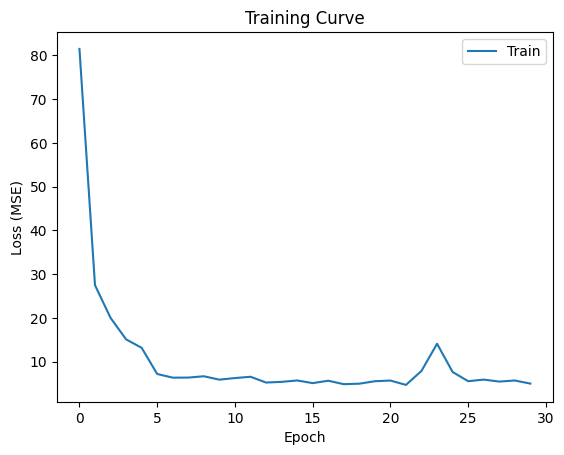

In [44]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Train")
# Validation losses were not recorded in the training loop
# plt.plot(val_losses, label="Val")
plt.legend()
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.show()

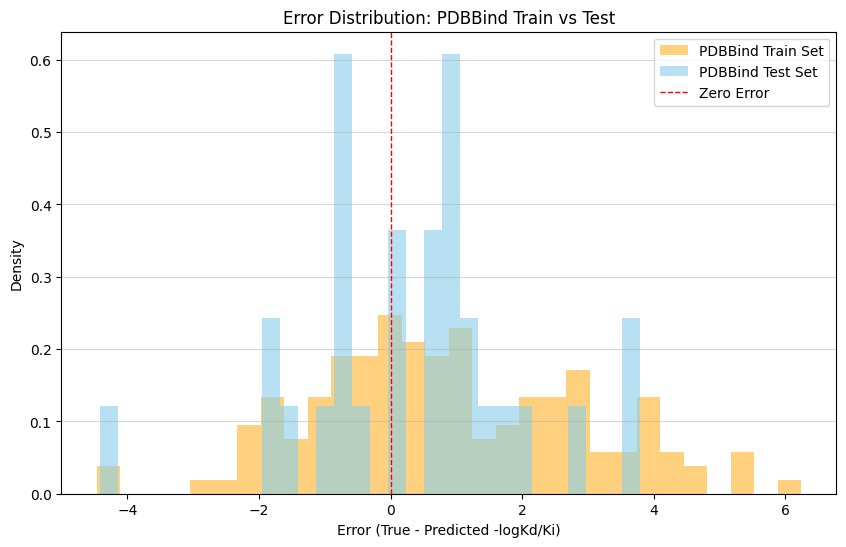

In [45]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Helper function to get predictions (re-defined here for safety)
def get_preds_safe(loader, model):
    model.eval()
    all_preds = []
    all_true = []
    with torch.no_grad():
        # Correctly unpack the tuple (ligand_batch, protein_batch, y)
        for ligand_batch, protein_batch, y in loader:
            ligand_batch = ligand_batch.to(device)
            protein_batch = protein_batch.to(device)

            # Pass both inputs to the DualGNN model
            pred = model(ligand_batch, protein_batch)

            all_preds.append(pred.view(-1).cpu().numpy())
            all_true.append(y.view(-1).cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_preds)

# 1. Compute Errors for PDBBind Train and Test sets
# (Using the existing loaders and model)
y_train_true, y_train_pred = get_preds_safe(train_loader, model)
y_test_true, y_test_pred = get_preds_safe(test_loader, model)

train_errors = y_train_true - y_train_pred
test_errors = y_test_true - y_test_pred

# 2. Plotting
plt.figure(figsize=(10, 6))

# Plot Train Errors
plt.hist(train_errors, bins=30, color='orange', alpha=0.5, label='PDBBind Train Set', density=True)
# Plot Test Errors
plt.hist(test_errors, bins=30, color='skyblue', alpha=0.6, label='PDBBind Test Set', density=True)

plt.axvline(x=0, color='red', linestyle='--', linewidth=1, label='Zero Error')
plt.title("Error Distribution: PDBBind Train vs Test")
plt.xlabel("Error (True - Predicted -logKd/Ki)")
plt.ylabel("Density")
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()